# Notebook 02 — Event Definition & Detection
**Thesis Chapter 6** | **Input:** `data/1_reconstructed.csv` | **Output:** `data/2_events.csv`

---

## What this notebook does

Adds 12 event indicator columns to the reconstructed dataset blus B.
An **event** is a binary or categorical condition at the time of each received packet.  
Example: *"Was CO₂ above 700 ppm when this packet arrived?"*

| Family | Events  | Why it matters                                                         |
|--------|---------|------------------------------------------------------------------------|
| Occupancy (CO₂) | E1, E2  | CO₂ is the best non-invasive proxy for human presence                  |
| Temporal | E3–E5   | Office activity follows predictable daily, weekly, and seasonal cycles |
| Air Quality (PM2.5) | E6, E7  | PM2.5 spikes mark activity bursts — cleaning, printing, cooking        |
| Atmospheric | E8, E9  | Temperature, Humidity                                                  |
| TX Config | E10     | SF controls Time-on-Air and therefore collision probability            |
| Signal Context | E11, E12 | RSSI/ESP — proxy for channel state at the time of each interval        |
| Burst Loss | ~ | Classifies loss episodes by severity                                   |

Notebook 03 correlates these events with `PDR_link` (outage intervals excluded).

## 0 · Imports & Load

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '1_reconstructed.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id','time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Campaign: {df["time"].min().date()} → {df["time"].max().date()}')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign: 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family':'serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB',
     'brown':'#882255','teal':'#44AA99','yellow':'#DDCC77'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf')
    fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()

print('Figures settings ready.')


Figures settings ready.


## 1 · Occupancy Events — CO₂  *(§6.1)*

CO₂ rises linearly with the number of people present — human metabolism produces ~200 ml CO₂/min at rest.  
Outdoor ambient is ~420 ppm. Weekday mean in this building is ~576 ppm vs ~457 ppm on weekends,  
confirming CO₂ as a reliable occupancy proxy.

| Event | Definition                                                         |
|-------|--------------------------------------------------------------------|
| E1 | CO₂ tier: background (<500) / moderate (500–700) / high (>700 ppm) |
| E2 | CO₂ rising: delta > 15 ppm per 60s — occupancy actively increasing |

In [3]:
# E1: CO2 tier — 500 ppm = outdoor ambient ceiling, 700 ppm = moderate occupancy onset
df['e1_co2_tier'] = pd.cut(
    df['co2'],
    bins=[0, 500, 700, 10_000],
    labels=['background', 'moderate', 'high']
)

# E2: CO2 rising — delta > 15 ppm/60s signals people arriving
# 15 ppm chosen to exceed BME280 sensor noise (~±10 ppm)
df['e2_co2_rising'] = (
        df.groupby('device_id')['co2'].diff() > 15
).astype(int)

print('CO2 tier distribution (E1):')
print(df['e1_co2_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(
    f'\nCO2 rising intervals (E2): {df["e2_co2_rising"].sum():,}  ({df["e2_co2_rising"].mean() * 100:.1f}% of all intervals)')
print(f'CO2 mean overall         : {df["co2"].mean():.0f} ppm  |  std: {df["co2"].std():.0f} ppm')

CO2 tier distribution (E1):
e1_co2_tier
background    63.4%
moderate      28.2%
high           8.4%

CO2 rising intervals (E2): 6,430  (0.2% of all intervals)
CO2 mean overall         : 516 ppm  |  std: 117 ppm


  Saved: figures/02_a_co2_distribution


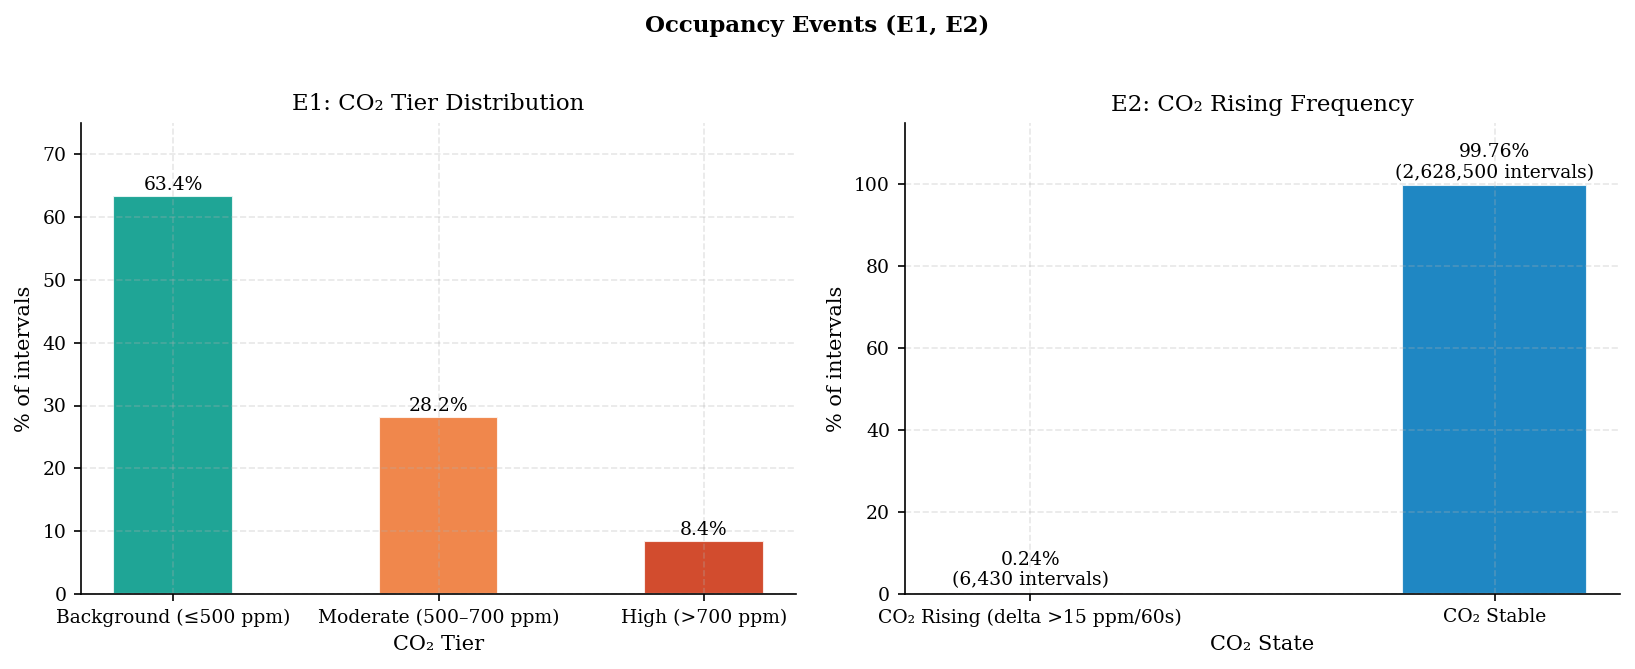

In [23]:
# Fig 02-A — CO₂ Tier Distribution (E1) + CO₂ Rising Rate (E2)
tiers  = ['background','moderate','high']
xlabs  = ['Background (≤500 ppm)','Moderate (500–700 ppm)','High (>700 ppm)']
pcts   = df['e1_co2_tier'].value_counts(normalize=True).reindex(tiers).fillna(0)*100
rising_count = int(df['e2_co2_rising'].sum())
rising_rate  = float(df['e2_co2_rising'].mean()*100)
stable_rate  = 100 - rising_rate

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left: E1 CO2 tier distribution
bars = axes[0].bar(xlabs, pcts.values,
                    color=[C['green'],C['orange'],C['red']],
                    width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('CO\u2082 Tier')
axes[0].set_ylim(0, 75)
axes[0].set_title('E1: CO\u2082 Tier Distribution')

# right: E2 — linear scale, annotate count to show rarity
stable_count = int(len(df) - rising_count)
bars2 = axes[1].bar(
    ['CO\u2082 Rising (delta >15 ppm/60s)', 'CO\u2082 Stable'],
    [rising_rate, stable_rate],
    color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white'
)
for bar, v, cnt in zip(bars2, [rising_rate, stable_rate],
                        [rising_count, stable_count]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.8,
                 f'{v:.2f}%\n({cnt:,} intervals)',
                 ha='center', va='bottom', fontsize=9, )
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('CO\u2082 State')
axes[1].set_ylim(0, 115)
axes[1].set_title('E2: CO\u2082 Rising Frequency')

fig.suptitle('Occupancy Events (E1, E2)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(top=0.82)   # prevent suptitle collision
save_fig(fig, '02_a_co2_distribution')

## 2 · Temporal Events  *(§6.2)*

Converted to `Europe/Berlin` local time — handles both DST transitions  
(October 2024 and March 2025) automatically.

| Event | Definition |
|-------|-----------|
| E3 | Weekday (1) vs weekend (0) — coarsest occupancy signal |
| E4 | Time-of-day band: night / morning / peak / evening |
| E5 | Office hours — weekday AND 08:00–17:59 |
| E6 | Season — autumn / winter / spring across 34-week campaign |

In [5]:
# local time — required for correct hour/weekday extraction across DST boundaries
local = df['time'].dt.tz_convert('Europe/Berlin')
df['hour']      = local.dt.hour
df['dayofweek'] = local.dt.dayofweek   # 0=Monday, 6=Sunday
df['month']     = local.dt.month

# E3: weekday vs weekend
df['e3_is_weekday'] = (df['dayofweek'] < 5).astype(int)

# E4: office hours — weekday AND 08:00–17:59
df['e4_office_hours'] = (
    (df['e3_is_weekday'] == 1) & df['hour'].between(8, 17)
).astype(int)

# E5: season
df['e5_season'] = df['month'].map({
     9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter',  1: 'winter',  2: 'winter',
     3: 'spring',  4: 'spring',  5: 'spring',
     6: 'summer',  7: 'summer',  8: 'summer',
})

print(f'Weekday share (E3)    : {df["e3_is_weekday"].mean()*100:.1f}%')
print(f'Office hours (E4)     : {df["e4_office_hours"].mean()*100:.1f}%')
print(f'Season (E5)           : {df["e5_season"].value_counts().to_dict()}')


Weekday share (E3)    : 70.7%
Office hours (E4)     : 29.2%
Season (E5)           : {'autumn': 703823, 'spring': 688573, 'summer': 648905, 'winter': 593629}


  Saved: figures/02_b_temporal_distributions


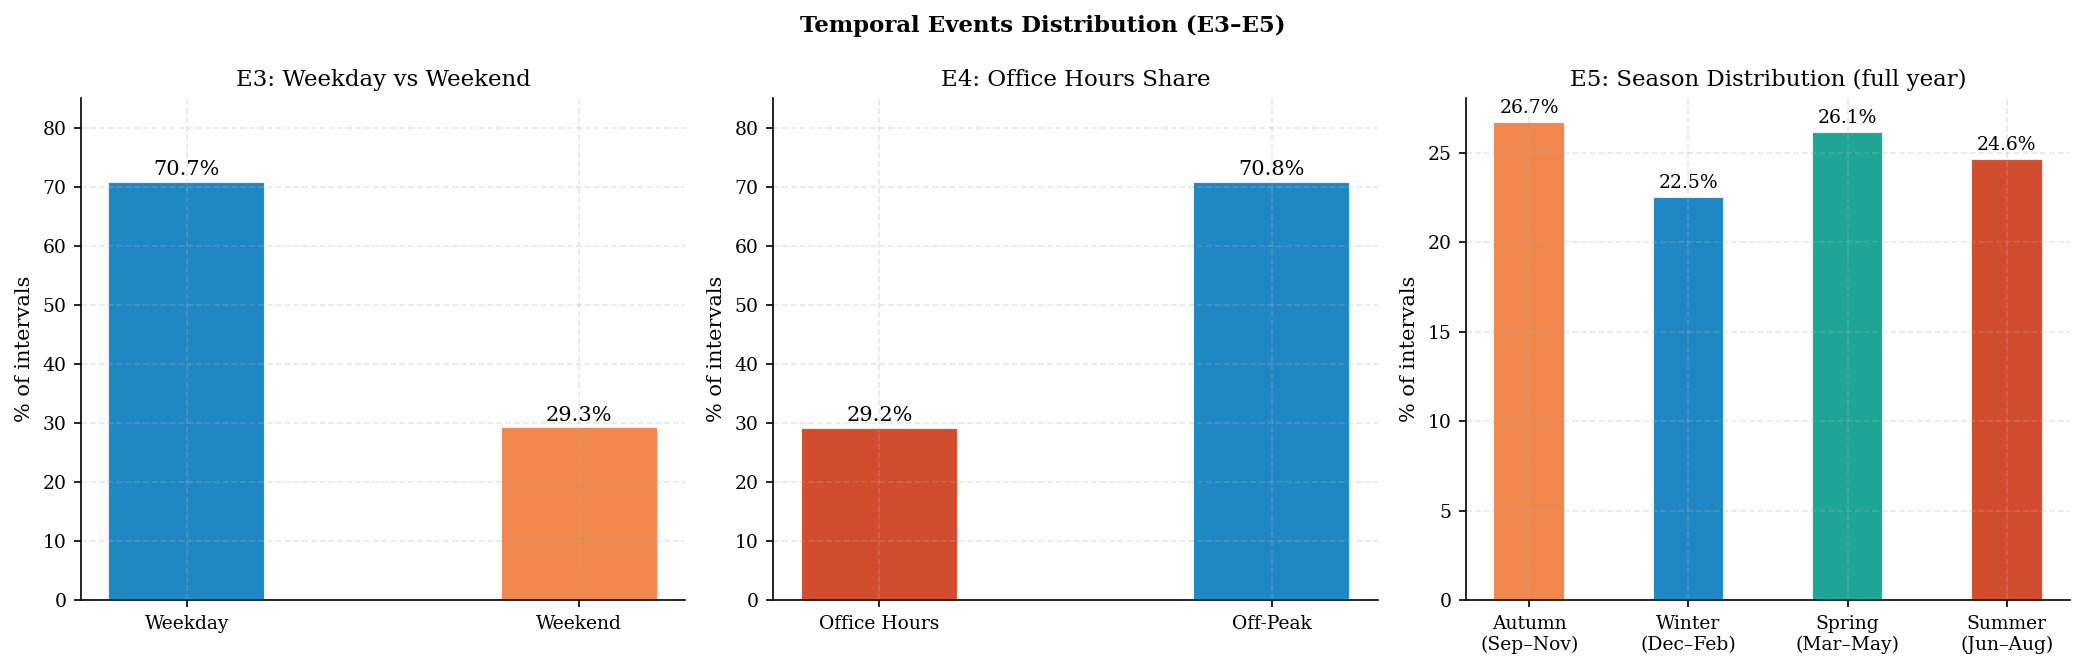

In [6]:
# Fig 02-B — Temporal Event Distributions (E3–E5)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# E3: weekday vs weekend
wk = df['e3_is_weekday'].mean()*100
axes[0].bar(['Weekday','Weekend'], [wk, 100-wk],
             color=[C['blue'],C['orange']], width=0.4, alpha=0.88, edgecolor='white')
for i2, v in enumerate([wk, 100-wk]):
    axes[0].text(i2, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, 85); axes[0].set_ylabel('% of intervals')
axes[0].set_title('E3: Weekday vs Weekend')

# E4: office hours
oh = df['e4_office_hours'].mean()*100
axes[1].bar(['Office Hours','Off-Peak'], [oh, 100-oh],
             color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i2, v in enumerate([oh, 100-oh]):
    axes[1].text(i2, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 85); axes[1].set_ylabel('% of intervals')
axes[1].set_title('E4: Office Hours Share')

# E5: season
seasons = ['autumn','winter','spring','summer']
slabs = ['Autumn\n(Sep–Nov)','Winter\n(Dec–Feb)','Spring\n(Mar–May)','Summer\n(Jun–Aug)']
scounts = [df['e5_season'].eq(s).mean()*100 for s in seasons]
bars = axes[2].bar(slabs, scounts,
                    color=[C['orange'],C['blue'],C['green'],C['red']],
                    width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, scounts):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('% of intervals')
axes[2].set_title('E5: Season Distribution (full year)')

fig.suptitle('Temporal Events Distribution (E3–E5)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_b_temporal_distributions')


## 3 · Air Quality Events — PM2.5  *(§6.3)*

PM2.5 correlates with human activity bursts — cleaning, printing, cooking —  
rather than directly attenuating 868 MHz signals.

Device-specific 90th percentile thresholds for E7 account for location differences:  
ED4 (server room) baseline = 0.79 µg/m³ vs ED5 (kitchen) baseline = 6.28 µg/m³.  
A global threshold would over-flag ED5 and under-flag ED4.

| Event | Definition |
|-------|-----------|
| E6    | PM2.5 spike: above device-specific 90th percentile |
| E7    | PM2.5 absolute tier: clean (<2) / moderate (2–10) / elevated (>10 µg/m³) |

In [7]:
# E6: device-specific PM2.5 spike — 90th percentile per device
pm25_q90 = df.groupby('device_id')['pm25'].transform(lambda x: x.quantile(0.90))
df['e6_pm25_spike'] = (df['pm25'] > pm25_q90).astype(int)

# E7: absolute WHO-aligned tier
df['e7_pm25_tier'] = pd.cut(
    df['pm25'],
    bins=[-0.01, 2, 10, 10_000],
    labels=['clean', 'moderate', 'elevated']
)

print('Device-specific PM2.5 90th percentile thresholds:')
print(df.groupby('device_id')['pm25'].quantile(0.90).round(2).to_string())
print(f'\nSpike rate (E7=1): {df["e6_pm25_spike"].mean() * 100:.1f}%')

Device-specific PM2.5 90th percentile thresholds:
device_id
ED0    4.54
ED1    4.66
ED2    4.40
ED3    4.85
ED4    1.01
ED5    6.49

Spike rate (E7=1): 10.0%


  Saved: figures/02_c_pm25_events


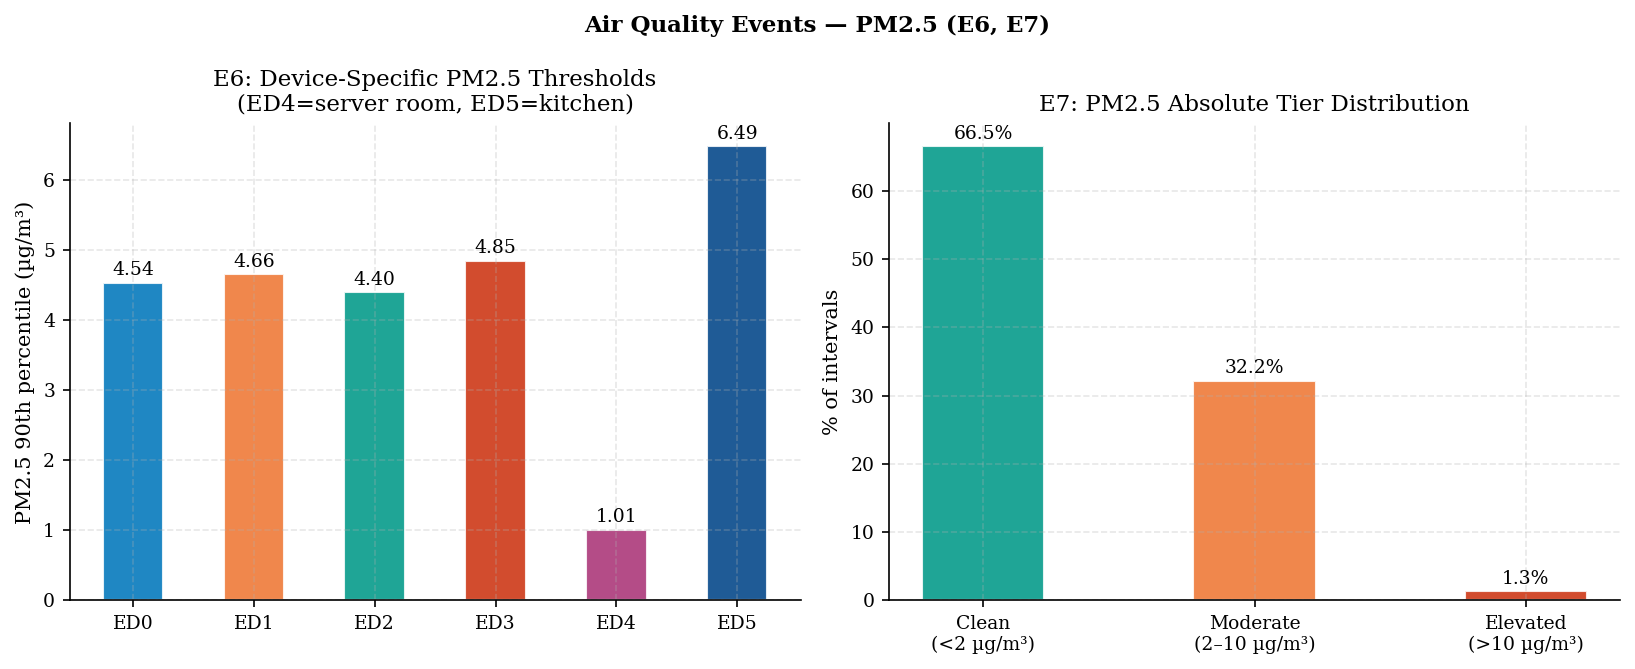

In [8]:
# Fig 02-C — PM2.5 Device Thresholds and Tier Distribution
DEVICES_L = sorted(df['device_id'].unique())
pm25_q90 = df.groupby('device_id')['pm25'].quantile(0.90)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(DEVICES_L, [pm25_q90[d] for d in DEVICES_L], color=DEVICE_COLORS[:len(DEVICES_L)],
             width=0.5, alpha=0.88, edgecolor='white')
for i,(dev,v) in enumerate(zip(DEVICES_L,[pm25_q90[d] for d in DEVICES_L])):
    axes[0].text(i, v+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('PM2.5 90th percentile (\u00b5g/m\u00b3)')
axes[0].set_title('E6: Device-Specific PM2.5 Thresholds\n(ED4=server room, ED5=kitchen)')

pm_tiers=['clean','moderate','elevated']
pm_labs=['Clean\n(<2 \u00b5g/m\u00b3)','Moderate\n(2–10 \u00b5g/m\u00b3)','Elevated\n(>10 \u00b5g/m\u00b3)']
pm_pcts=[df['e7_pm25_tier'].eq(t).mean()*100 for t in pm_tiers]
bars=axes[1].bar(pm_labs,pm_pcts,color=[C['green'],C['orange'],C['red']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,pm_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2,v+0.5,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[1].set_ylabel('% of intervals'); axes[1].set_title('E7: PM2.5 Absolute Tier Distribution')

fig.suptitle('Air Quality Events — PM2.5 (E6, E7)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_c_pm25_events')


## 4 · Atmospheric Events  *(§6.4)*

| Event | Definition |
|-------|-----------|
| E8   | Temperature tier: campaign quartiles — HVAC set-point shifts seasonally |
| E9    | Humidity tier: dry (<40%) / normal (40–55%) / humid (55–70%) / very_humid (>70%) |



In [9]:
# E8: temperature tier — quartile-based (TEMP FIRST)
df['e8_temp_tier'] = pd.qcut(
    df['temperature'], q=4,
    labels=['cold', 'cool', 'warm', 'hot'],
    duplicates='drop'
)

# E9: humidity tier — absolute bands
df['e9_humidity_tier'] = pd.cut(
    df['humidity'],
    bins=[0, 40, 55, 70, 101],
    labels=['dry', 'normal', 'humid', 'very_humid']
)

print(f'Temperature range: {df["temperature"].min():.1f} – {df["temperature"].max():.1f} °C')
print(f'Humidity range   : {df["humidity"].min():.1f} – {df["humidity"].max():.1f} %')


Temperature range: 13.7 – 46.3 °C
Humidity range   : 14.0 – 62.8 %


  Saved: figures/02_d_atmospheric_distributions


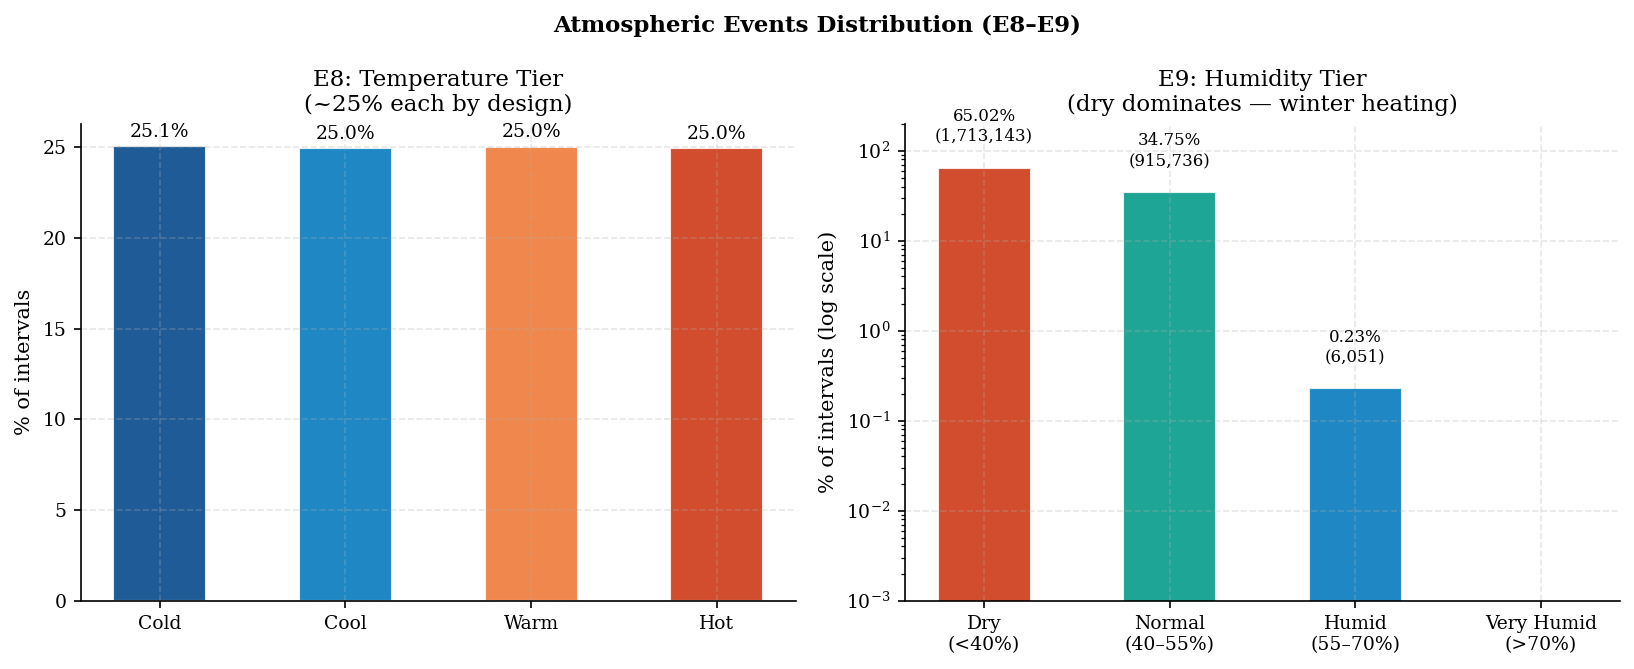

In [10]:
# Fig 02-D — Atmospheric Event Distributions (E8–E9)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# E8: temperature tier
tt = ['cold','cool','warm','hot']
tt_labs = ['Cold','Cool','Warm','Hot']
tt_pcts = [df['e8_temp_tier'].eq(t).mean()*100 for t in tt]
bars = axes[0].bar(tt_labs, tt_pcts,
                    color=[C['navy'],C['blue'],C['orange'],C['red']],
                    width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_title('E8: Temperature Tier\n(~25% each by design)')

# E9: humidity tier — log scale to show the tail categories
ht = ['dry','normal','humid','very_humid']
ht_labs = ['Dry\n(<40%)', 'Normal\n(40–55%)', 'Humid\n(55–70%)', 'Very Humid\n(>70%)']
ht_pcts = [df['e9_humidity_tier'].eq(t).mean()*100 for t in ht]
ht_counts = [df['e9_humidity_tier'].eq(t).sum() for t in ht]
bars = axes[1].bar(ht_labs, ht_pcts,
                    color=[C['red'],C['green'],C['blue'],C['navy']],
                    width=0.5, alpha=0.88, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_ylim(bottom=0.001, top=200)
for bar, v, cnt in zip(bars, ht_pcts, ht_counts):
    if v > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, v*1.8,
                     f'{v:.2f}%\n({cnt:,})', ha='center', va='bottom', fontsize=8)
axes[1].set_ylabel('% of intervals (log scale)')
axes[1].set_title('E9: Humidity Tier\n(dry dominates — winter heating)')

fig.suptitle('Atmospheric Events Distribution (E8\u2013E9)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_d_atmospheric_distributions')

## 5 · Transmission Configuration Events  *(§6.5)*

SF directly controls Time-on-Air (ToA) — the duration a packet occupies the channel.  
Under LoRaWAN's ALOHA protocol, longer ToA = wider collision window = higher loss probability.

ADR was disabled. SF rotated in a fixed cycle: SF12→SF11→SF10→SF9→SF8→SF7.  
SF11/SF12 blocks are truncated to 4 packets by duty cycle enforcement (§5.2.1).

| SF | ToA (ms) | Collision window vs SF7 |
|----|---------|------------------------|
| 7 | 71.9 | baseline |
| 8 | 133.6 | 1.9× |
| 9 | 246.8 | 3.4× |
| 10 | 452.6 | 6.3× |
| 11 | 987.1 | 13.7× |
| 12 | 1810.4 | 25.2× |

| Event | Definition |
|-------|-----------|
| E10  | SF categorical: 7 / 8 / 9 / 10 / 11 / 12 |


In [11]:
# E10: individual SF value
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
df['e10_sf'] = df['SF'].astype(int)

print('SF Distribution (E10):')
for sf in [7,8,9,10,11,12]:
    n = (df['e10_sf']==sf).sum()
    print(f'  SF{sf} (ToA={TOA_MS[sf]:7.1f}ms): {n:,} ({n/len(df)*100:.1f}%)')


SF Distribution (E10):
  SF7 (ToA=   71.9ms): 537,023 (20.4%)
  SF8 (ToA=  133.6ms): 534,546 (20.3%)
  SF9 (ToA=  246.8ms): 518,734 (19.7%)
  SF10 (ToA=  452.6ms): 500,838 (19.0%)
  SF11 (ToA=  987.1ms): 269,220 (10.2%)
  SF12 (ToA= 1810.4ms): 274,569 (10.4%)


  Saved: figures/02_e_sf_distribution


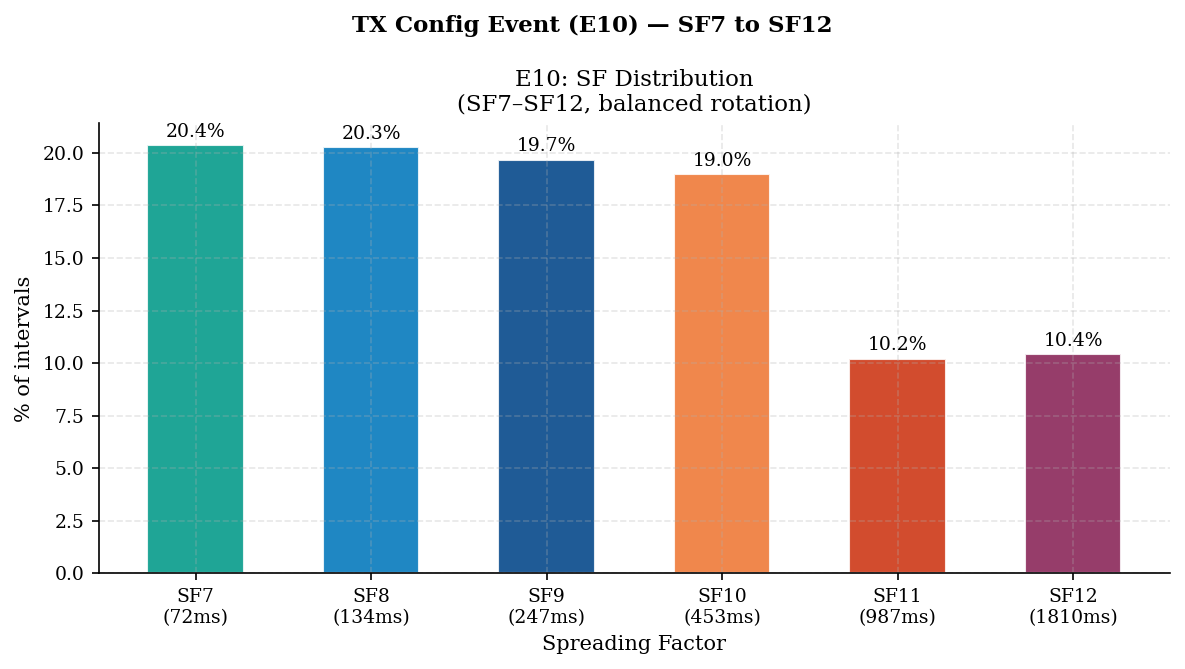

In [12]:
# Fig 02-E — SF Distribution (E10)
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
fig, ax = plt.subplots(figsize=(8, 4.5))

sfs = [7,8,9,10,11,12]
sf_xlabs  = [f'SF{sf}\n({TOA_MS[sf]:.0f}ms)' for sf in sfs]
sf_pcts   = [df['e10_sf'].eq(sf).mean()*100 for sf in sfs]
sf_colors = [C['green'],C['blue'],C['navy'],C['orange'],C['red'],C['brown']]
bars = ax.bar(sf_xlabs, sf_pcts, color=sf_colors, width=0.55, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, sf_pcts):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of intervals')
ax.set_xlabel('Spreading Factor')
ax.set_title('E10: SF Distribution\n(SF7–SF12, balanced rotation)')

fig.suptitle('TX Config Event (E10) — SF7 to SF12', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_e_sf_distribution')


## 6 · Signal Context Events  *(§6.6)*

RSSI and ESP are only available for received packets — never for lost ones.  
E11 and E11 use the signal quality of the packet received immediately before the loss interval
as a proxy for channel state at the time of loss.

| Event | Definition |
|-------|-----------|
| E11   | RSSI tier: weak (<−90) / moderate (−90 to −70) / strong (>−70 dBm) |
| E12   | ESP tier: campaign tertile-based — ESP combines RSSI and SNR (§2.2.3) |


In [13]:
# E11: RSSI tier
df['e11_rssi_tier'] = pd.cut(
    df['rssi'],
    bins=[-200, -90, -70, 0],
    labels=['weak', 'moderate', 'strong']
)

# E12: ESP tier — tertile-based, no obvious physical breakpoints
df['e12_esp_tier'] = pd.qcut(
    df['esp'], q=3,
    labels=['low_esp', 'medium_esp', 'high_esp'],
    duplicates='drop'
)

print('RSSI tier distribution (E14):')
print(df['e11_rssi_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(f'\nRSSI range: {df["rssi"].min():.0f} to {df["rssi"].max():.0f} dBm')
print(f'ESP  range: {df["esp"].min():.1f} to {df["esp"].max():.1f} dBm')


RSSI tier distribution (E14):
e11_rssi_tier
strong      48.1%
weak        26.0%
moderate    25.9%

RSSI range: -128 to -28 dBm
ESP  range: -146.5 to -28.4 dBm


  Saved: figures/02_f_signal_context_distribution


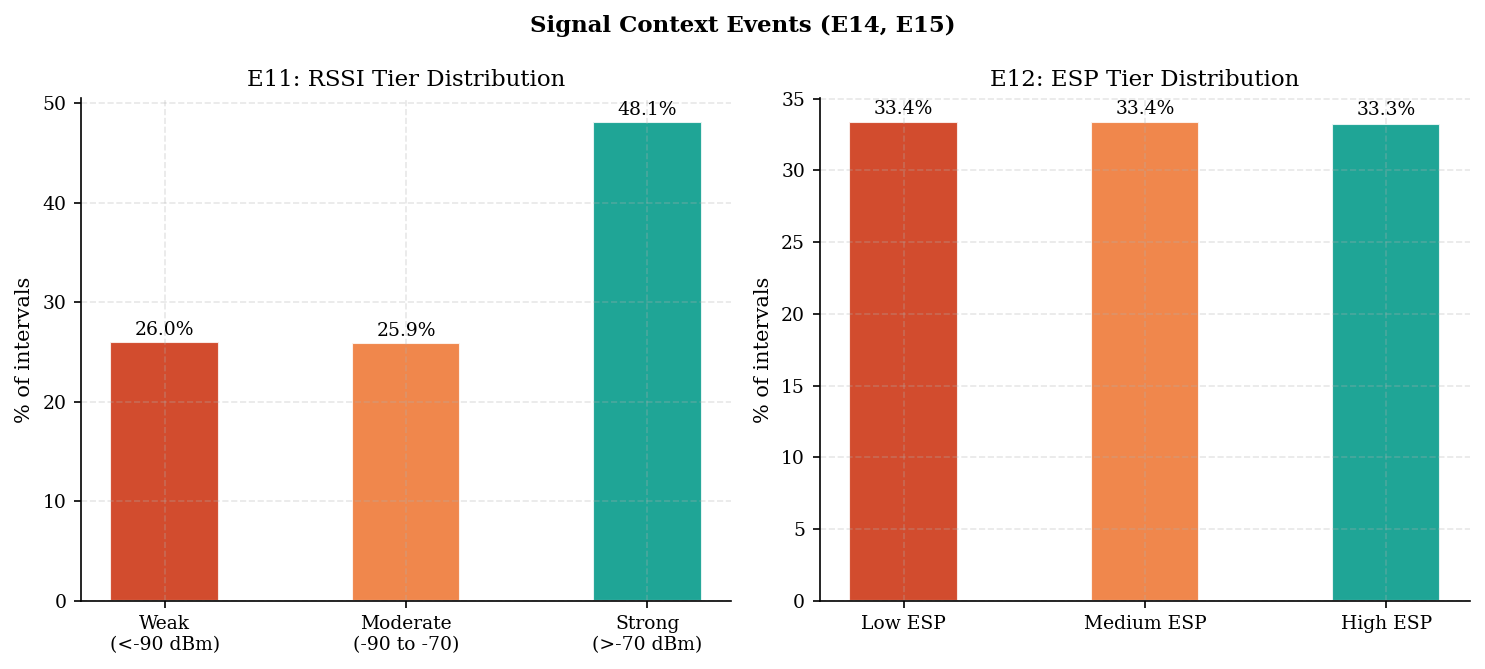

In [14]:
# Fig 02-F — Signal Context Events (E11, E12)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

rt     = ['weak','moderate','strong']
rt_labs = ['Weak\n(<-90 dBm)','Moderate\n(-90 to -70)','Strong\n(>-70 dBm)']
rt_pcts = [df['e11_rssi_tier'].eq(t).mean()*100 for t in rt]
bars = axes[0].bar(rt_labs, rt_pcts,
                    color=[C['red'],C['orange'],C['green']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,rt_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_title('E11: RSSI Tier Distribution')

et     = ['low_esp','medium_esp','high_esp']
et_labs = ['Low ESP','Medium ESP','High ESP']
et_pcts = [df['e12_esp_tier'].eq(t).mean()*100 for t in et]
bars = axes[1].bar(et_labs, et_pcts,
                    color=[C['red'],C['orange'],C['green']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,et_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('% of intervals')
axes[1].set_title('E12: ESP Tier Distribution')

fig.suptitle('Signal Context Events (E14, E15)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_f_signal_context_distribution')


## 7 · Burst Loss Event  *(§6.7)*

Classifies each interval by the number of consecutive packets lost before the received packet.  
Burst loss is qualitatively different from isolated loss — it creates contiguous data gaps  
that cannot be recovered by interpolation.

**B=3 threshold:** 3 consecutive losses = 3-minute gap at 60s TX interval — the minimum  
gap that visibly disrupts slowly-varying environmental signals (CO₂, temperature).

| Class | Condition | Interpretation |
|-------|-----------|---------------|
| no_loss | 0 | Clean reception |
| isolated | 1 | Single random collision |
| small_burst | 2–4 | Brief channel degradation |
| large_burst | ≥5 | Sustained interference episode |


In [15]:
# Burst loss characterisation — descriptive only, NOT an event predictor
# Classifies each interval by tx_loss magnitude for Figure 02-G
# This column is used for descriptive analysis only and is excluded
# from all Mann-Whitney tests and logistic regression (outcome circularity)
df['loss_type'] = pd.cut(
    df['tx_loss'],
    bins=[-1, 0, 1, 4, 10_000_000],
    labels=['no_loss', 'isolated', 'small_burst', 'large_burst']
)

print('Burst loss distribution (descriptive):')
print(df['loss_type'].value_counts(normalize=True).mul(100).round(2).astype(str).add('%').to_string())


Burst loss distribution (descriptive):
loss_type
no_loss        98.34%
isolated        1.33%
small_burst     0.27%
large_burst     0.05%


  Saved: figures/02_g_burst_loss_distribution


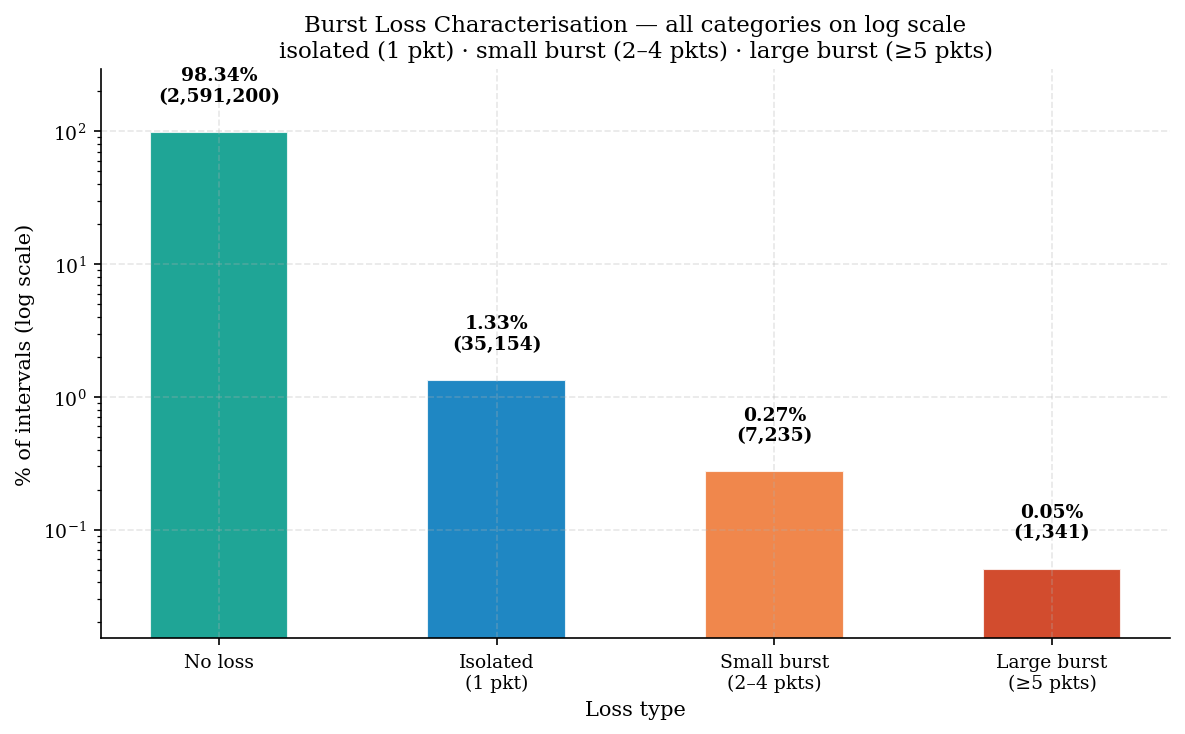

In [16]:
# Fig 02-G — Burst Loss Distribution (single log panel)
order  = ['no_loss', 'isolated', 'small_burst', 'large_burst']
olabs  = ['No loss', 'Isolated\n(1 pkt)', 'Small burst\n(2–4 pkts)', 'Large burst\n(≥5 pkts)']

# cast to string first to bypass Categorical comparison issues
loss_str = df['loss_type'].astype(str)
o_pcts   = [float((loss_str == o).mean() * 100) for o in order]
o_counts = [int((loss_str == o).sum()) for o in order]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(olabs, o_pcts,
               color=[C['green'], C['blue'], C['orange'], C['red']],
               width=0.5, alpha=0.88, edgecolor='white')
ax.set_yscale('log')
ax.set_ylim(
    bottom=min(v for v in o_pcts if v > 0) * 0.3,
    top=max(o_pcts) * 3
)
for bar, v, cnt in zip(bars, o_pcts, o_counts):
    ax.text(bar.get_x()+bar.get_width()/2, v * 1.6,
            f'{v:.2f}%\n({cnt:,})', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.set_ylabel('% of intervals (log scale)')
ax.set_xlabel('Loss type')
ax.set_title('Burst Loss Characterisation — all categories on log scale\n'
             'isolated (1 pkt) \u00b7 small burst (2\u20134 pkts) \u00b7 large burst (\u22655 pkts)')
fig.tight_layout()
save_fig(fig, '02_g_burst_loss_distribution')

## 8 · Event Taxonomy  *(Table 6.1)*

Complete list of all 17 events — copy to Table 6.1 in the thesis.


In [17]:
# Event Taxonomy — 12 events E1–E12
event_taxonomy = [
    ('E1',  'Occupancy',      'e1_co2_tier',      'CO2 concentration tier (background/moderate/high)'),
    ('E2',  'Occupancy',      'e2_co2_rising',     'CO2 rising > 20ppm/60s'),
    ('E3',  'Temporal',       'e3_is_weekday',     'Weekday vs weekend'),
    ('E4',  'Temporal',       'e4_office_hours',   'Office hours — weekday AND 08:00–17:59'),
    ('E5',  'Temporal',       'e5_season',         'Season (autumn/winter/spring/summer)'),
    ('E6',  'Air Quality',    'e6_pm25_spike',     'PM2.5 device-specific 90th percentile spike'),
    ('E7',  'Air Quality',    'e7_pm25_tier',      'PM2.5 absolute tier (clean/moderate/elevated)'),
    ('E8',  'Atmospheric',    'e8_temp_tier',      'Temperature quartile tier (cold/cool/warm/hot)'),
    ('E9',  'Atmospheric',    'e9_humidity_tier',  'Relative humidity tier (dry/normal/humid)'),
    ('E10', 'TX Config',      'e10_sf',            'Spreading factor (SF7–SF12)'),
    ('E11', 'Signal Context', 'e11_rssi_tier',     'RSSI tier (weak/moderate/strong)'),
    ('E12', 'Signal Context', 'e12_esp_tier',      'ESP tier (low/medium/high)'),
]

print(f"{'ID':<5} {'Family':<15} {'Column':<22} {'Definition'}")
print('-'*80)
for row in event_taxonomy:
    print(f'{row[0]:<5} {row[1]:<15} {row[2]:<22} {row[3]}')
print(f'\nTotal: {len(event_taxonomy)} events across 6 families (E1–E12)')


ID    Family          Column                 Definition
--------------------------------------------------------------------------------
E1    Occupancy       e1_co2_tier            CO2 concentration tier (background/moderate/high)
E2    Occupancy       e2_co2_rising          CO2 rising > 20ppm/60s
E3    Temporal        e3_is_weekday          Weekday vs weekend
E4    Temporal        e4_office_hours        Office hours — weekday AND 08:00–17:59
E5    Temporal        e5_season              Season (autumn/winter/spring/summer)
E6    Air Quality     e6_pm25_spike          PM2.5 device-specific 90th percentile spike
E7    Air Quality     e7_pm25_tier           PM2.5 absolute tier (clean/moderate/elevated)
E8    Atmospheric     e8_temp_tier           Temperature quartile tier (cold/cool/warm/hot)
E9    Atmospheric     e9_humidity_tier       Relative humidity tier (dry/normal/humid)
E10   TX Config       e10_sf                 Spreading factor (SF7–SF12)
E11   Signal Context  e11_rssi_tier   

## Save  *(2_events.csv)*

| Group | Columns |
|-------|---------|
| Original | all columns from `1_reconstructed.csv` |
| Occupancy | `e1_co2_tier`, `e2_co2_rising` |
| Temporal | `e3_is_weekday`, `e4_office_hours`, `e5_season` |
| Air Quality | `e6_pm25_spike`, `e7_pm25_tier` |
| Atmospheric | `e8_temp_tier`, `e9_humidity_tier` |
| TX Config | `e10_sf` |
| Signal Context | `e11_rssi_tier`, `e12_esp_tier` |


In [18]:
original_cols = [c for c in df.columns
                 if not (c.startswith('e') and '_' in c)
                 and c not in ['hour', 'dayofweek', 'month', 'exp_pl']]

event_cols_ordered = [
    'e1_co2_tier',   'e2_co2_rising',
    'e3_is_weekday', 'e4_office_hours', 'e5_season',
    'e6_pm25_spike', 'e7_pm25_tier',
    'e8_temp_tier',  'e9_humidity_tier',
    'e10_sf',
    'e11_rssi_tier', 'e12_esp_tier',
    'loss_type',
]

df = df[[c for c in original_cols if c in df.columns] +
        [c for c in event_cols_ordered if c in df.columns]]
df.to_csv(DATA_DIR / '2_events.csv', index=False)

print(f'Saved  : {DATA_DIR / "2_events.csv"}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {len(df.columns)} total | 12 events (E1–E12) + loss_type')


Saved  : ..\data\2_events.csv
Rows   : 2,634,930
Columns: 40 total | 12 events (E1–E12) + loss_type
